# Random Forest Classification on Glass Dataset

## Data Preparation

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import ConfusionMatrixDisplay 

In [2]:
file_path = "glass.xlsx"
# Inspecting Data
xls =  pd.ExcelFile(file_path)
xls.sheet_names

['Description', 'glass']

### Load both sheets separately

In [3]:
df_info = pd.read_excel(file_path, sheet_name="Description")  # Features description
df = pd.read_excel(file_path, sheet_name="glass")     # Main data

## 1. Exploratory Data Analysis (EDA)

### Dataset Structure

In [4]:
df_info

,Prepare a model for glass classification using Random Forest
0,Data Description:
1,RI : refractive index
2,Na: Sodium (unit measurement: weight percent i...
3,Mg: Magnesium
4,AI: Aluminum
5,Si: Silicon
6,K:Potassium
7,Ca: Calcium
8,Ba: Barium
9,Fe: Iron


In [5]:
# Basic info
df.head(), df.shape

(        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
 0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
 1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
 2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
 3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
 4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1,
 (214, 10))

### Statistical Summary

In [6]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


### Check Missing Values

In [7]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

### Duplicate Rows

In [8]:
df.duplicated().sum()

1

### Check Class Distribution (Imbalance)

In [9]:
# Percentage distribution
df['Type'].value_counts(normalize=True) * 100

Type
2    35.514019
1    32.710280
7    13.551402
3     7.943925
5     6.074766
6     4.205607
Name: proportion, dtype: float64

The percentage distribution shows that certain glass types dominate the dataset,
confirming the presence of class imbalance. To address this, class weights were
used during model training.

### Inconsistency Check (Zero Values)

In [10]:
print("\nZero Values per Feature:")
print((df == 0).sum())


Zero Values per Feature:
RI        0
Na        0
Mg       42
Al        0
Si        0
K        30
Ca        0
Ba      176
Fe      144
Type      0
dtype: int64


- No missing values were found in the dataset.
- Some features contain zero values which represent valid chemical measurements.
- Outliers are present but retained since they reflect real-world data.
- No major inconsistencies were observed.


## 2. Visualizations

### Histograms (Feature Distribution)

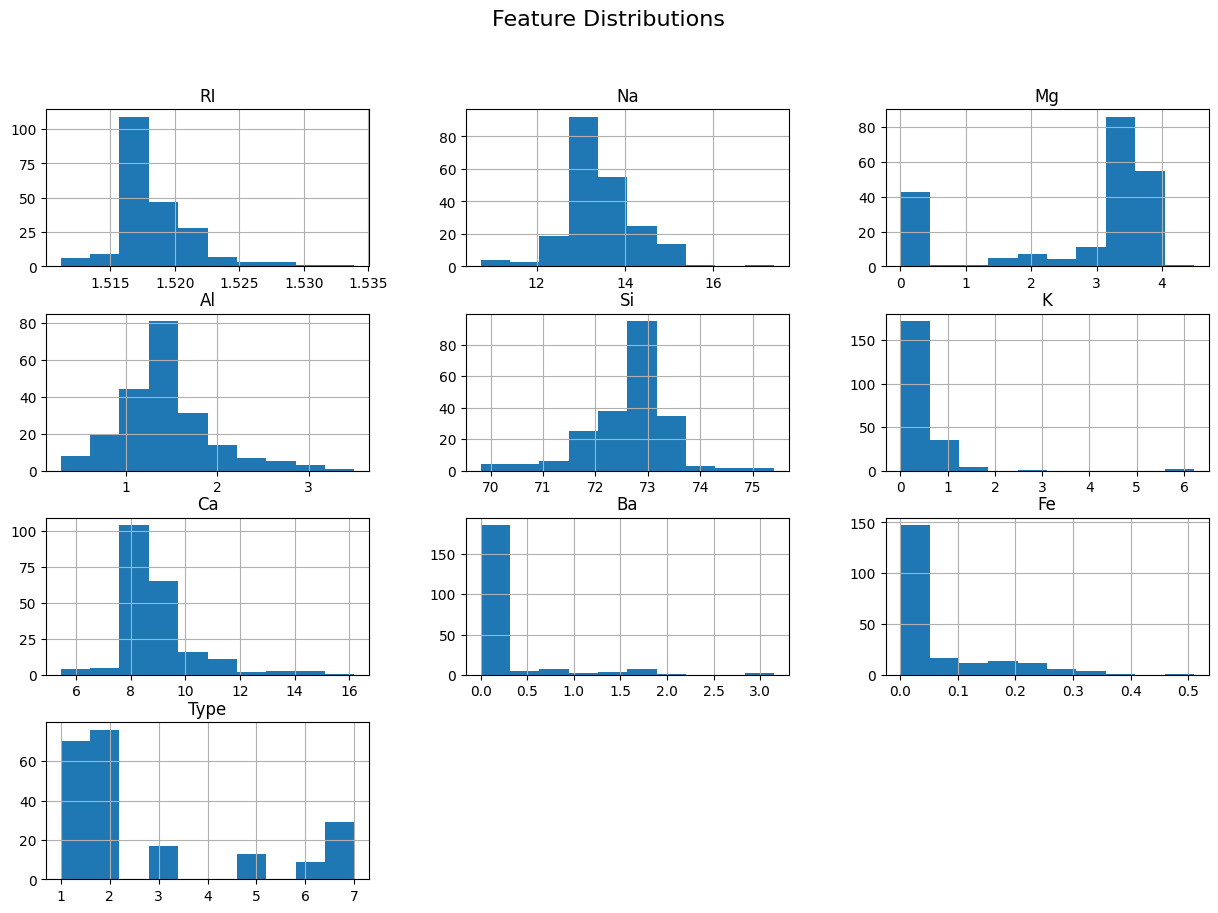

In [11]:
df.hist(figsize=(15, 10))
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

### Box Plots (Outlier Visualization)

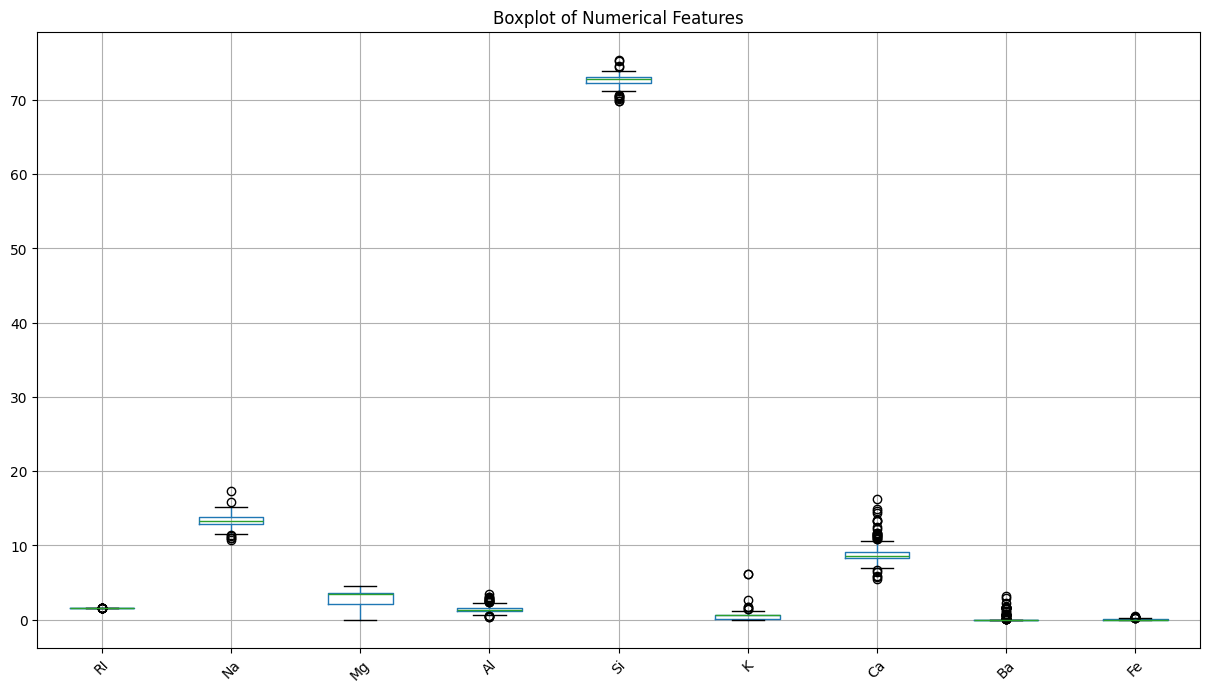

In [12]:
plt.figure(figsize=(15, 8))
df.drop(columns=['Type']).boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features")
plt.show()

### Correlation Heatmap

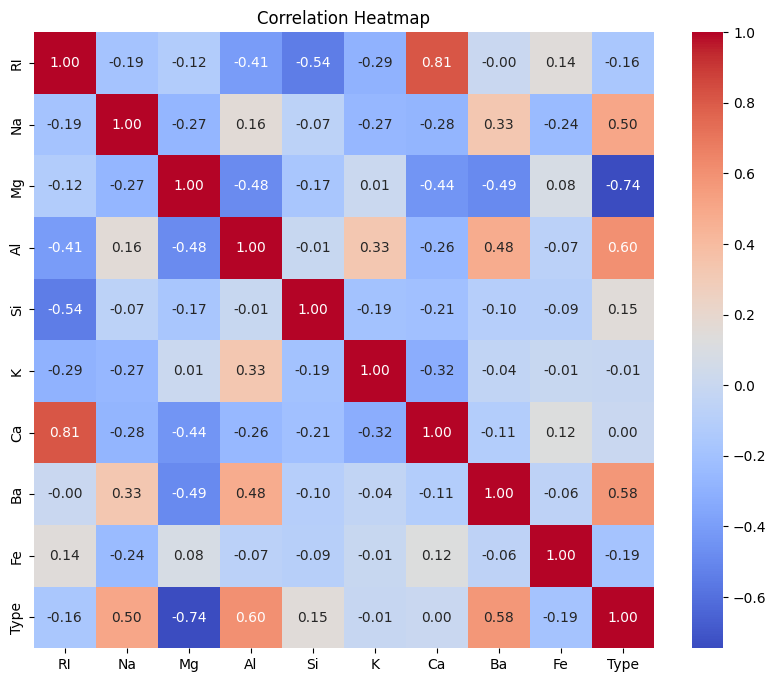

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Pair Plot (Selected Features)

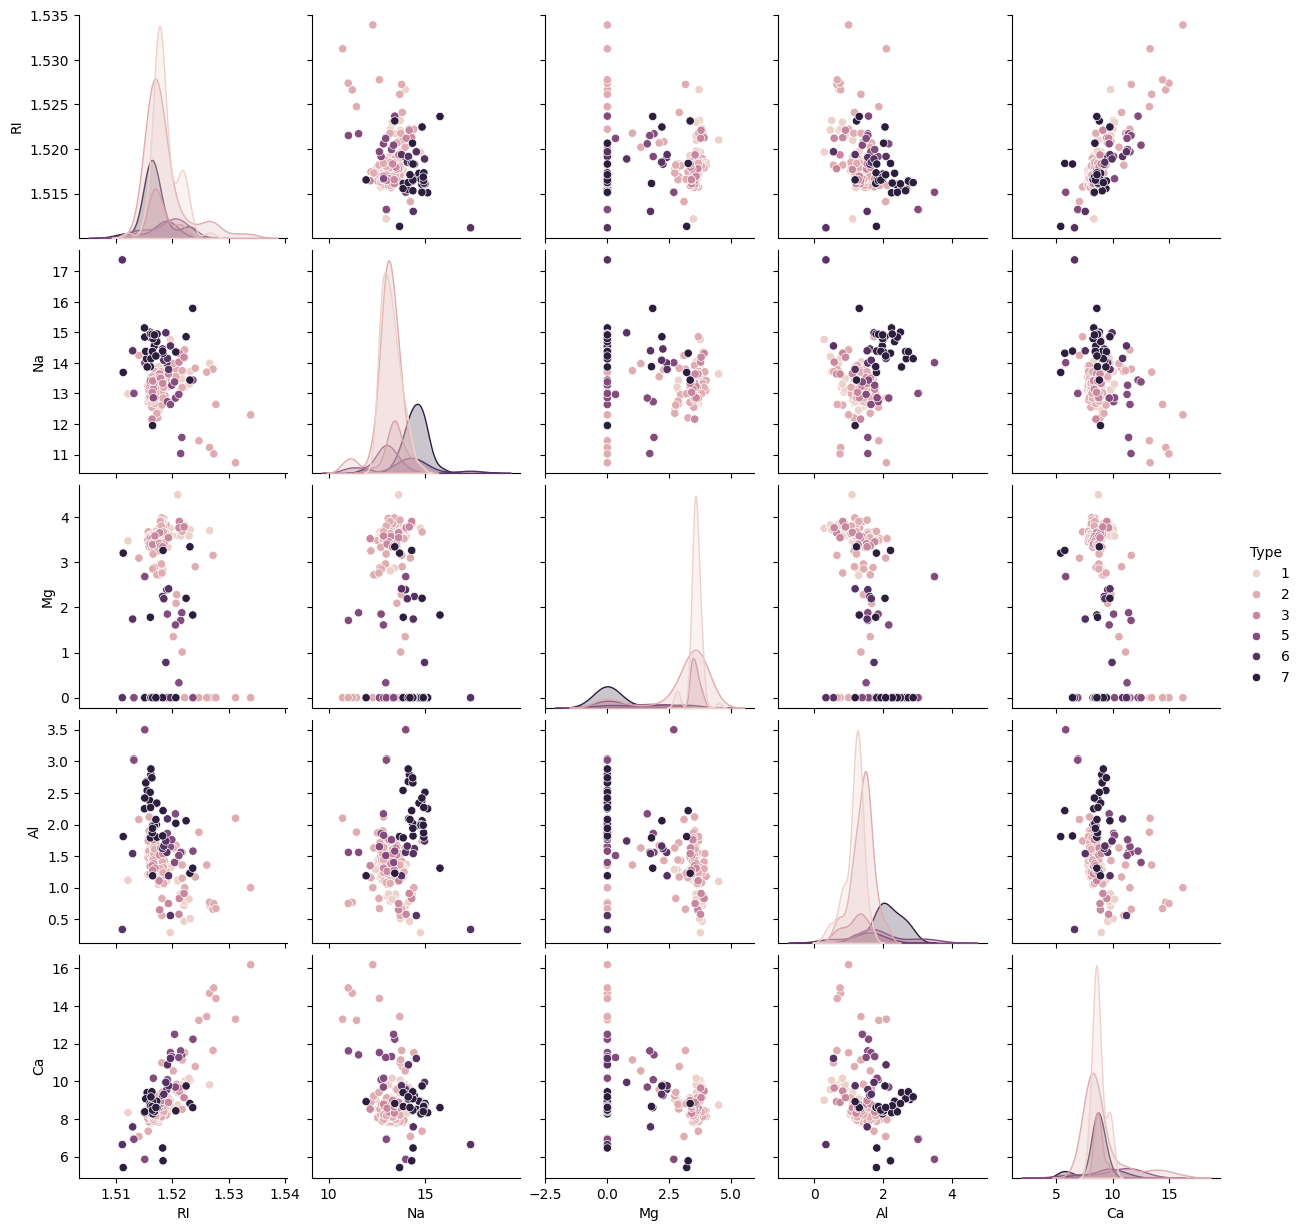

In [14]:
sns.pairplot(df[['RI','Na','Mg','Al','Ca','Type']], hue='Type')
plt.show()

- Most features show skewed distributions.
- K, Ba, and Fe contain extreme values.
- Moderate correlation is observed between Ca and RI.
- Certain features help distinguish glass types, making ensemble models suitable.

## 3. Data Preprocessing

### Missing Values Handling

*No missing values found - No imputation required

In [15]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

### Encoding Categorical Variables
* Not required (all variables are numeric)

In [16]:
df.dtypes

RI      float64
Na      float64
Mg      float64
Al      float64
Si      float64
K       float64
Ca      float64
Ba      float64
Fe      float64
Type      int64
dtype: object

### Feature Scaling

* Feature Scaling Justification

Tree-based models such as Random Forest and Bagging do not strictly require feature scaling.
However, scaling was applied to maintain consistency across all models and to enable a fair
comparison when evaluating multiple ensemble techniques.


In [17]:
X = df.drop(columns='Type')
y = df['Type']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Handling Imbalanced Data

In [18]:
y.value_counts()

Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64

In [19]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)

class_weight_dict = dict(zip(np.unique(y), class_weights))
class_weight_dict

{1: 0.5095238095238095,
 2: 0.4692982456140351,
 3: 2.0980392156862746,
 5: 2.7435897435897436,
 6: 3.962962962962963,
 7: 1.2298850574712643}

## 4. Random Forest Model Implementation

### Train–Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Random Forest Model

In [21]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight=class_weight_dict
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Model Evaluation

In [22]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.813953488372093
              precision    recall  f1-score   support

           1       0.75      0.86      0.80        14
           2       0.79      0.73      0.76        15
           3       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.81        43
   macro avg       0.87      0.85      0.84        43
weighted avg       0.83      0.81      0.81        43



## 5. Bagging and Boosting Methods

### Bagging (BaggingClassifier)

In [23]:
bagging = BaggingClassifier(
    estimator=RandomForestClassifier(random_state=42),
    n_estimators=50,
    random_state=42
)

bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)

print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))

Bagging Accuracy: 0.7906976744186046


### Confusion Matrix – Bagging

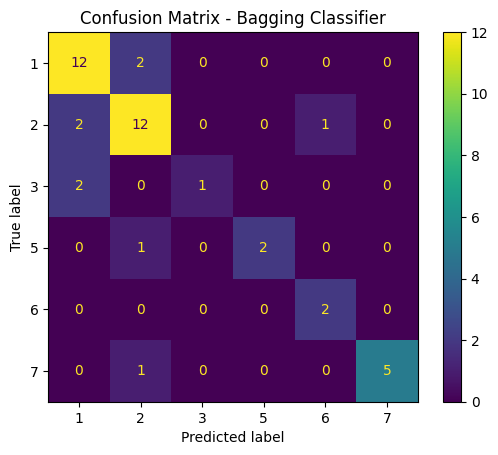

In [24]:
ConfusionMatrixDisplay.from_estimator(
    bagging,
    X_test,
    y_test
)
plt.title("Confusion Matrix - Bagging Classifier")
plt.show()

### Boosting (Gradient Boosting)

In [25]:
boosting = GradientBoostingClassifier(random_state=42)

boosting.fit(X_train, y_train)
y_pred_boost = boosting.predict(X_test)

print("Boosting Accuracy:", accuracy_score(y_test, y_pred_boost))

Boosting Accuracy: 0.813953488372093


### Confusion Matrix – Boosting

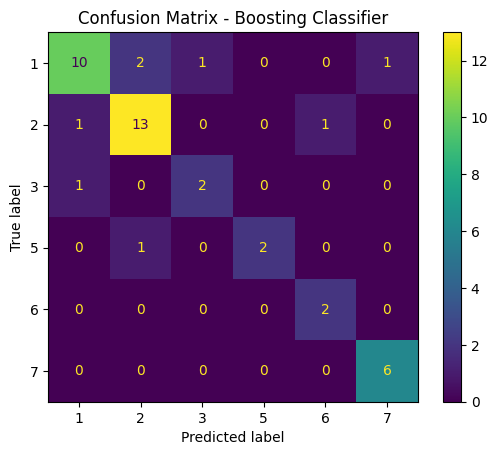

In [26]:
ConfusionMatrixDisplay.from_estimator(
    boosting,
    X_test,
    y_test
)
plt.title("Confusion Matrix - Boosting Classifier")
plt.show()

### Explicit Metrics Comparison Table

In [27]:
models = {
    "Random Forest": rf,
    "Bagging": bagging,
    "Boosting": boosting
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1-Score": f1_score(y_test, y_pred, average='weighted')
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.813953,0.828350,0.813953,0.814741
1,Bagging,0.790698,0.815891,0.790698,0.785290
2,Boosting,0.813953,0.821636,0.813953,0.811357


## Additional Notes


1. Bagging vs Boosting

* Bagging (Bootstrap Aggregating) is an ensemble learning method in which multiple models are trained independently on different bootstrapped samples of the dataset, and their predictions are combined using majority voting. It primarily helps in reducing variance and improving model stability. Random Forest is a widely used bagging-based algorithm.

* Boosting is an ensemble technique where models are trained sequentially, and each new model focuses more on correcting the errors made by previous models. Boosting aims to reduce bias and improve overall predictive performance. AdaBoost and XGBoost are common boosting algorithms.

* The key difference between bagging and boosting is that bagging trains models independently in parallel to reduce variance, whereas boosting trains models sequentially and gives more importance to misclassified samples to reduce bias.

2. Handling Imbalanced Data

* Imbalanced data occurs when some classes have significantly fewer samples than others, which can lead to biased predictions. Common techniques to handle imbalanced data include resampling methods such as oversampling (SMOTE) and undersampling, assigning higher class weights to minority classes, and using evaluation metrics like precision, recall, and F1-score instead of accuracy.

* In this assignment, class weight balancing was used while training the Random Forest model because it preserves the original data distribution, avoids generating synthetic samples, and works efficiently with tree-based ensemble models.
